In [3]:
# AVG_ATTN = True
# NUM = 38

In [4]:
# def visualize_attention(attn, hyp_tokens, src_tokens, heads=10):
#     """
#     Visualize attention heatmaps efficiently.

#     attn: [heads, tgt_len, src_len]
#     """
#     import matplotlib.pyplot as plt
#     import math

#     heads = min(heads, attn.shape[0])
#     print(f"Visualizing {heads} attention heads")
#     print(f"Attention shape: {attn.shape}")

#     # Determine grid layout
#     if heads > 2 and heads % 2 == 0:
#         nrows = 2
#         ncols = heads // 2
#     else:
#         nrows = 1
#         ncols = heads

#     fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)

#     # Flatten axes for easy indexing
#     if heads == 1:
#         axes = [axes]
#         attn = attn.unsqueeze(0)
#     else:
#         axes = axes.flatten()

#     for h in range(heads):
#         ax = axes[h]
#         im = ax.imshow(attn[h].cpu(), aspect='auto')

#         ax.set_xticks(range(len(src_tokens)))
#         ax.set_yticks(range(len(hyp_tokens)))

#         ax.set_xticklabels(src_tokens, rotation=90, fontsize=10)
#         ax.set_yticklabels(hyp_tokens, fontsize=10)

#         ax.set_title(f"Head {h}", fontsize=12)
#         # Smaller colorbar
#         fig.colorbar(im, ax=ax, fraction=0.05, pad=0.05)

#     plt.show()

In [5]:
def visualize_attention(attn, hyp_tokens, src_tokens, heads=10, average=False):
    import matplotlib.pyplot as plt

    print(f"Attention shape: {attn.shape}")

    if average:
        # [heads, tgt_len, src_len] → [tgt_len, src_len]
        attn = attn.mean(dim=0, keepdim=True)
        heads = 1
        print("Using averaged attention over heads")

    else:
        heads = min(heads, attn.shape[0])
        print(f"Visualizing {heads} attention heads")

    # layout
    if heads > 2 and heads % 2 == 0:
        nrows, ncols = 2, heads // 2
    else:
        nrows, ncols = 1, heads

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)

    if heads == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for h in range(heads):
        ax = axes[h]
        im = ax.imshow(attn[h].cpu(), aspect='auto')

        ax.set_xticks(range(len(src_tokens)))
        ax.set_yticks(range(len(hyp_tokens)))

        ax.set_xticklabels(src_tokens, rotation=90, fontsize=10)
        ax.set_yticklabels(hyp_tokens, fontsize=10)

        ax.set_title("Mean Attention" if average else f"Head {h}", fontsize=12)
        fig.colorbar(im, ax=ax, fraction=0.05, pad=0.05)

    plt.show()

In [6]:
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoTokenizer
from translation import TransformerEncoder, TransformerDecoder
# name = '2x_embedding_size_increase_dim__rnn_3_d_proper_sim_based_datasets_higher_5_temp_no_step_loss_from_90th_epoch_20_len'
name = 'proper_0th_epoch'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_path = f'/home/elena/emcomm/emcomm_captions/checkpoints/{name}/translation_t5_edit/checkpoint.pt'
def decoder_attention(sample_id):

    dataset = load_from_disk(f"/home/elena/emcomm/emcomm_captions/checkpoints/{name}/messages/coco_test_message_captions_3_distractors")
    sample = dataset[sample_id]

    tokenizer = AutoTokenizer.from_pretrained("t5-small")
    if tokenizer.bos_token is None:
        tokenizer.add_special_tokens({'bos_token': '<s>'})

    src = torch.tensor(sample["message_truncated"]).unsqueeze(0).to(DEVICE)
    ref_text = sample["captions"][0]

    tgt = tokenizer(ref_text, return_tensors="pt")["input_ids"].to(DEVICE)
    print('__________')
    print(f"Target text: {ref_text}")

    encoder = TransformerEncoder(
        vocab_size=71,
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=70,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    decoder = TransformerDecoder(
        vocab_size=len(tokenizer.vocab),
        emb_dim=256,
        hid_dim=512,
        num_layers=3,
        pad_id=tokenizer.pad_token_id,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    encoder.load_state_dict(checkpoint["encoder"])
    decoder.load_state_dict(checkpoint["decoder"])

    encoder.to(DEVICE).eval()
    decoder.to(DEVICE).eval()
    # decoder.transformer.layers[-1].multihead_attn.need_weights = True

    # ---------------- hook ----------------
    attention = {}

    layer = decoder.transformer.layers[-1].multihead_attn
    orig_forward = layer.forward

    def new_forward(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        out = orig_forward(*args, **kwargs)
        attention["weights"] = out[1].detach()
        return out

    layer.forward = new_forward

    def hook(module, input, output):
        attention["weights"] = output[1].detach()

    decoder.transformer.layers[-1].multihead_attn.register_forward_hook(hook)
    # --------------------------------------
    
    with torch.no_grad():
        memory, _ = encoder(src)

        bos_id = tokenizer.bos_token_id or tokenizer.pad_token_id
        eos_id = tokenizer.eos_token_id

        generated = torch.tensor([[bos_id]], device=DEVICE)

        max_len = 50  # adjust as needed

        for _ in range(max_len):
            logits, _, _ = decoder(generated, memory)

            next_token = logits[:, -1, :].argmax(-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)

            if eos_id is not None and (next_token == eos_id).all():
                break

    attn = attention["weights"][0]  # remove batch

    hyp_tokens = tokenizer.convert_ids_to_tokens(generated[0].tolist())
    src_tokens = [str(t.item()) for t in src[0]]

    visualize_attention(attn, hyp_tokens, src_tokens, average=False)


# if __name__ == "__main__":


__________
Target text: A man that is jumping in the air with a skateboard.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 20, 10])
Visualizing 8 attention heads


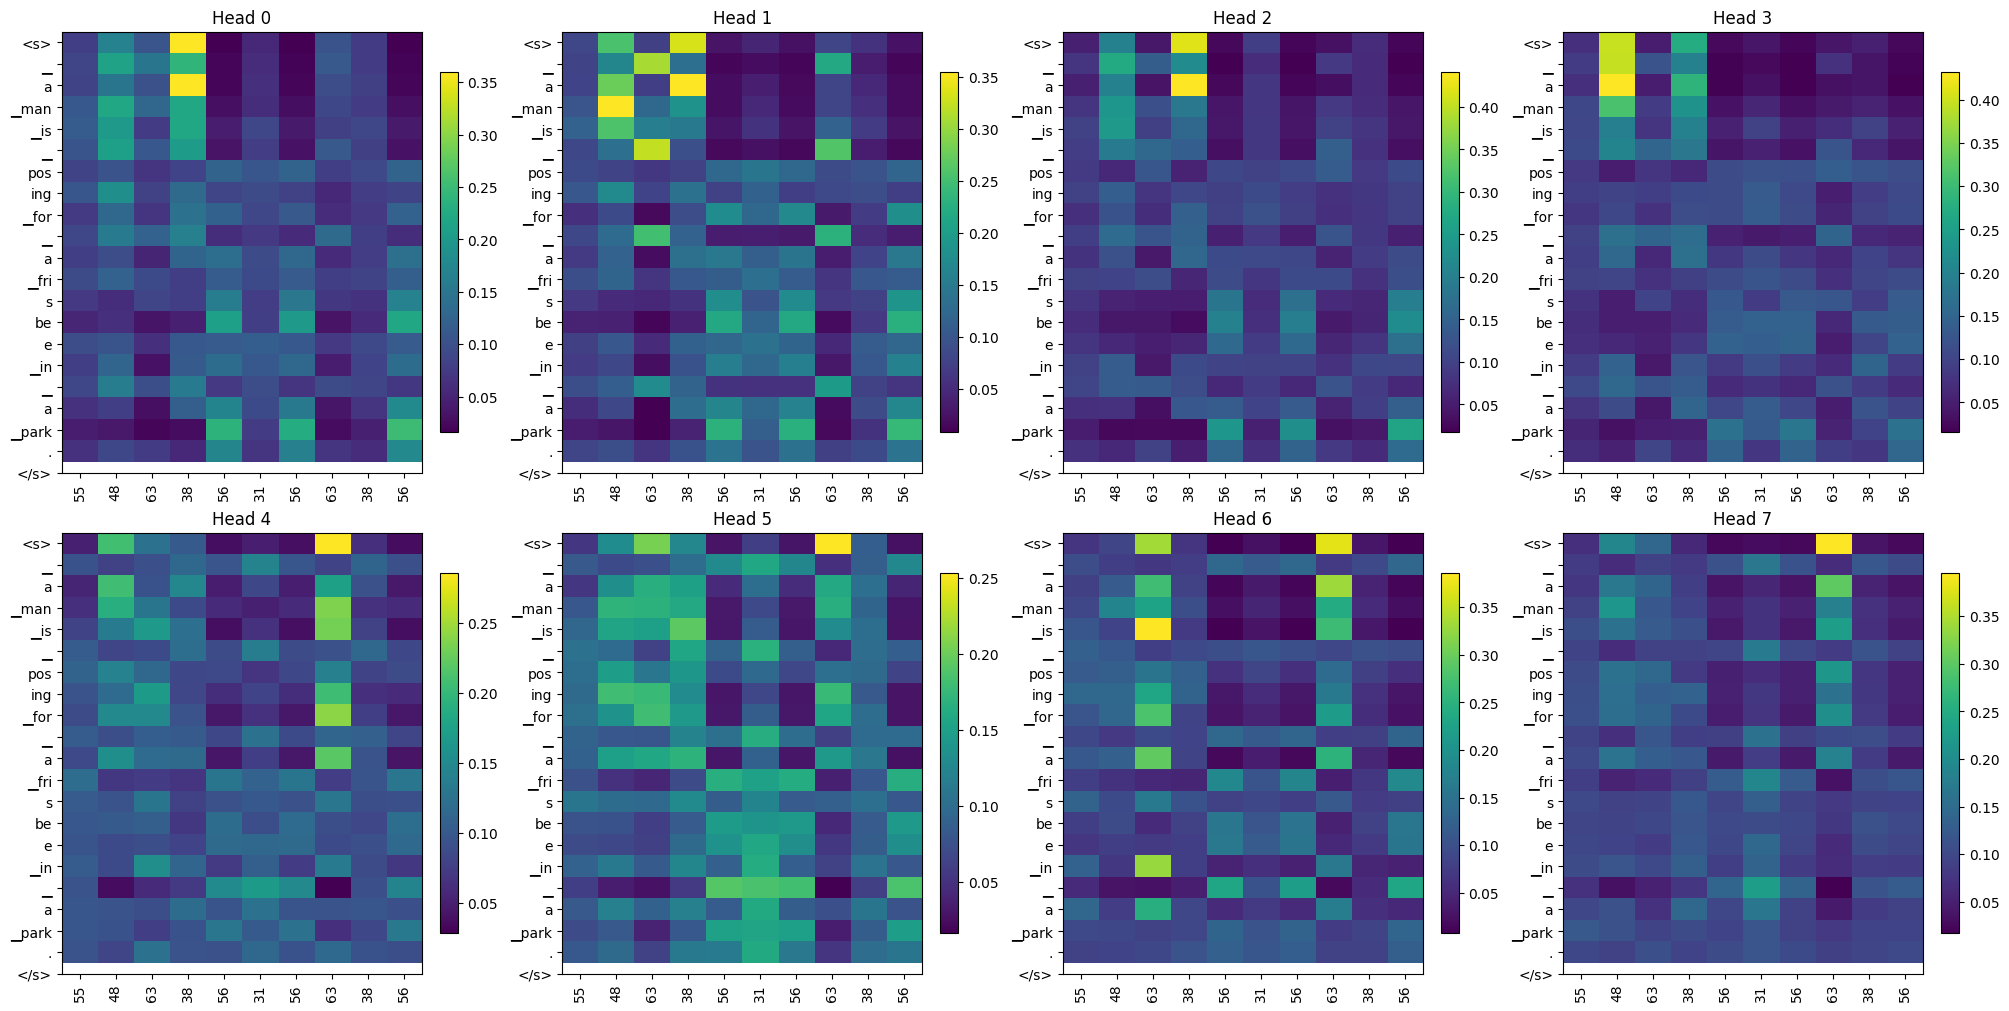

__
__________
Target text: A kitchen filled with a wooden cabinet and a large window.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 15, 10])
Visualizing 8 attention heads


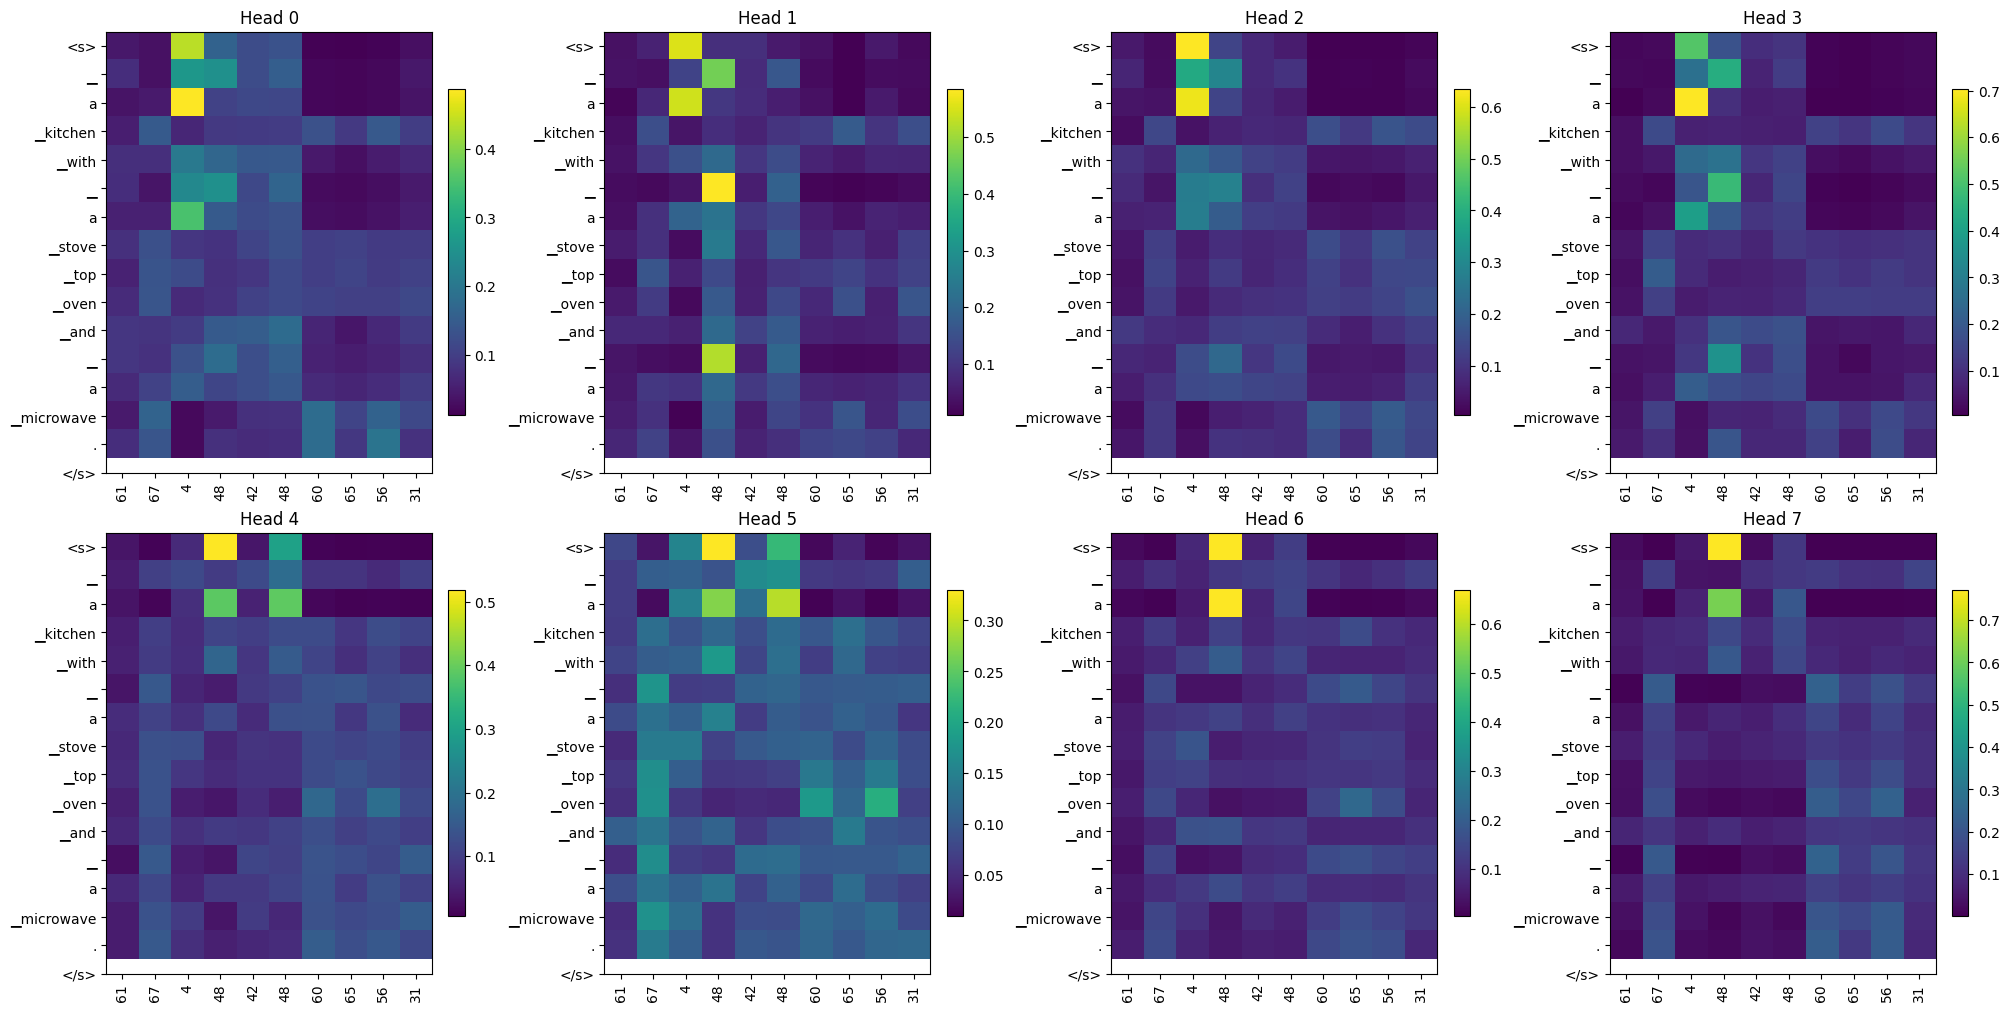

__
__________
Target text: A kid in a camo shirt riding a skateboard down the street.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 16, 10])
Visualizing 8 attention heads


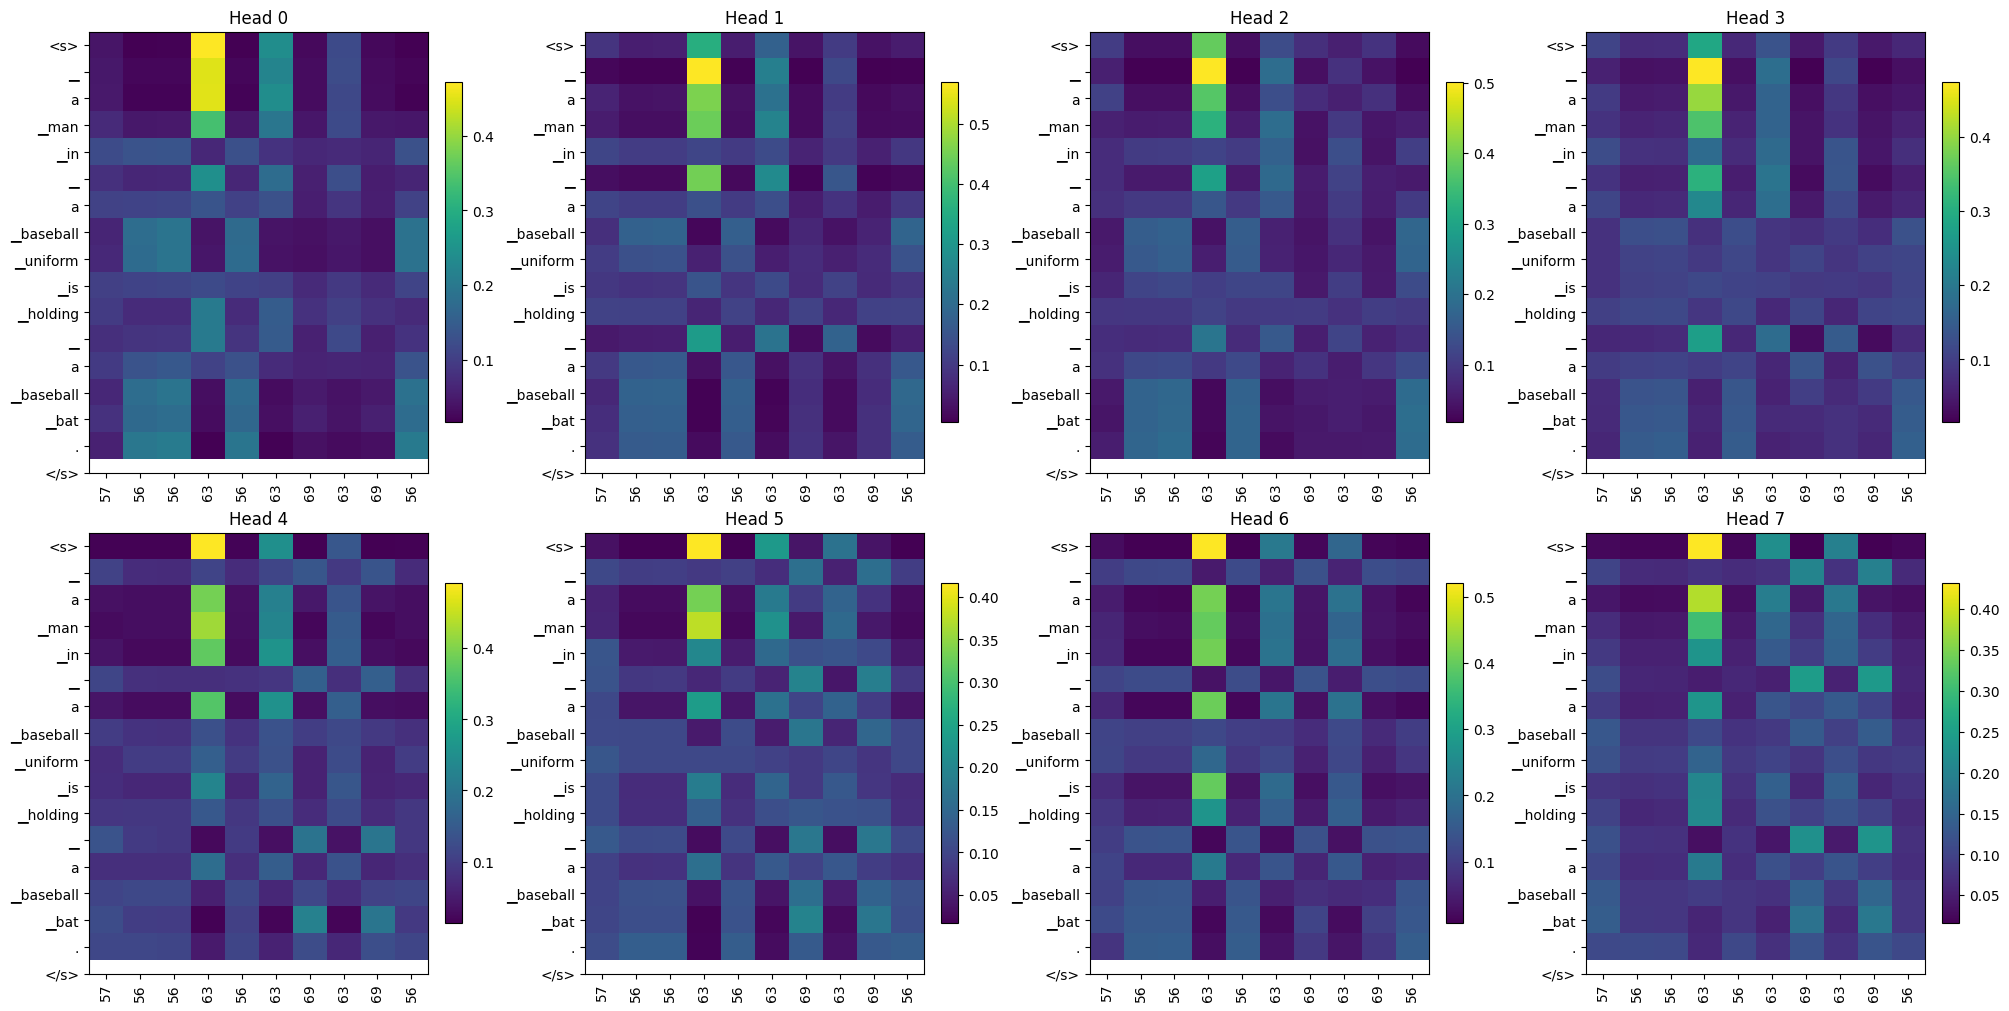

__
__________
Target text: A large digital clock mounted to a wall.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 19, 10])
Visualizing 8 attention heads


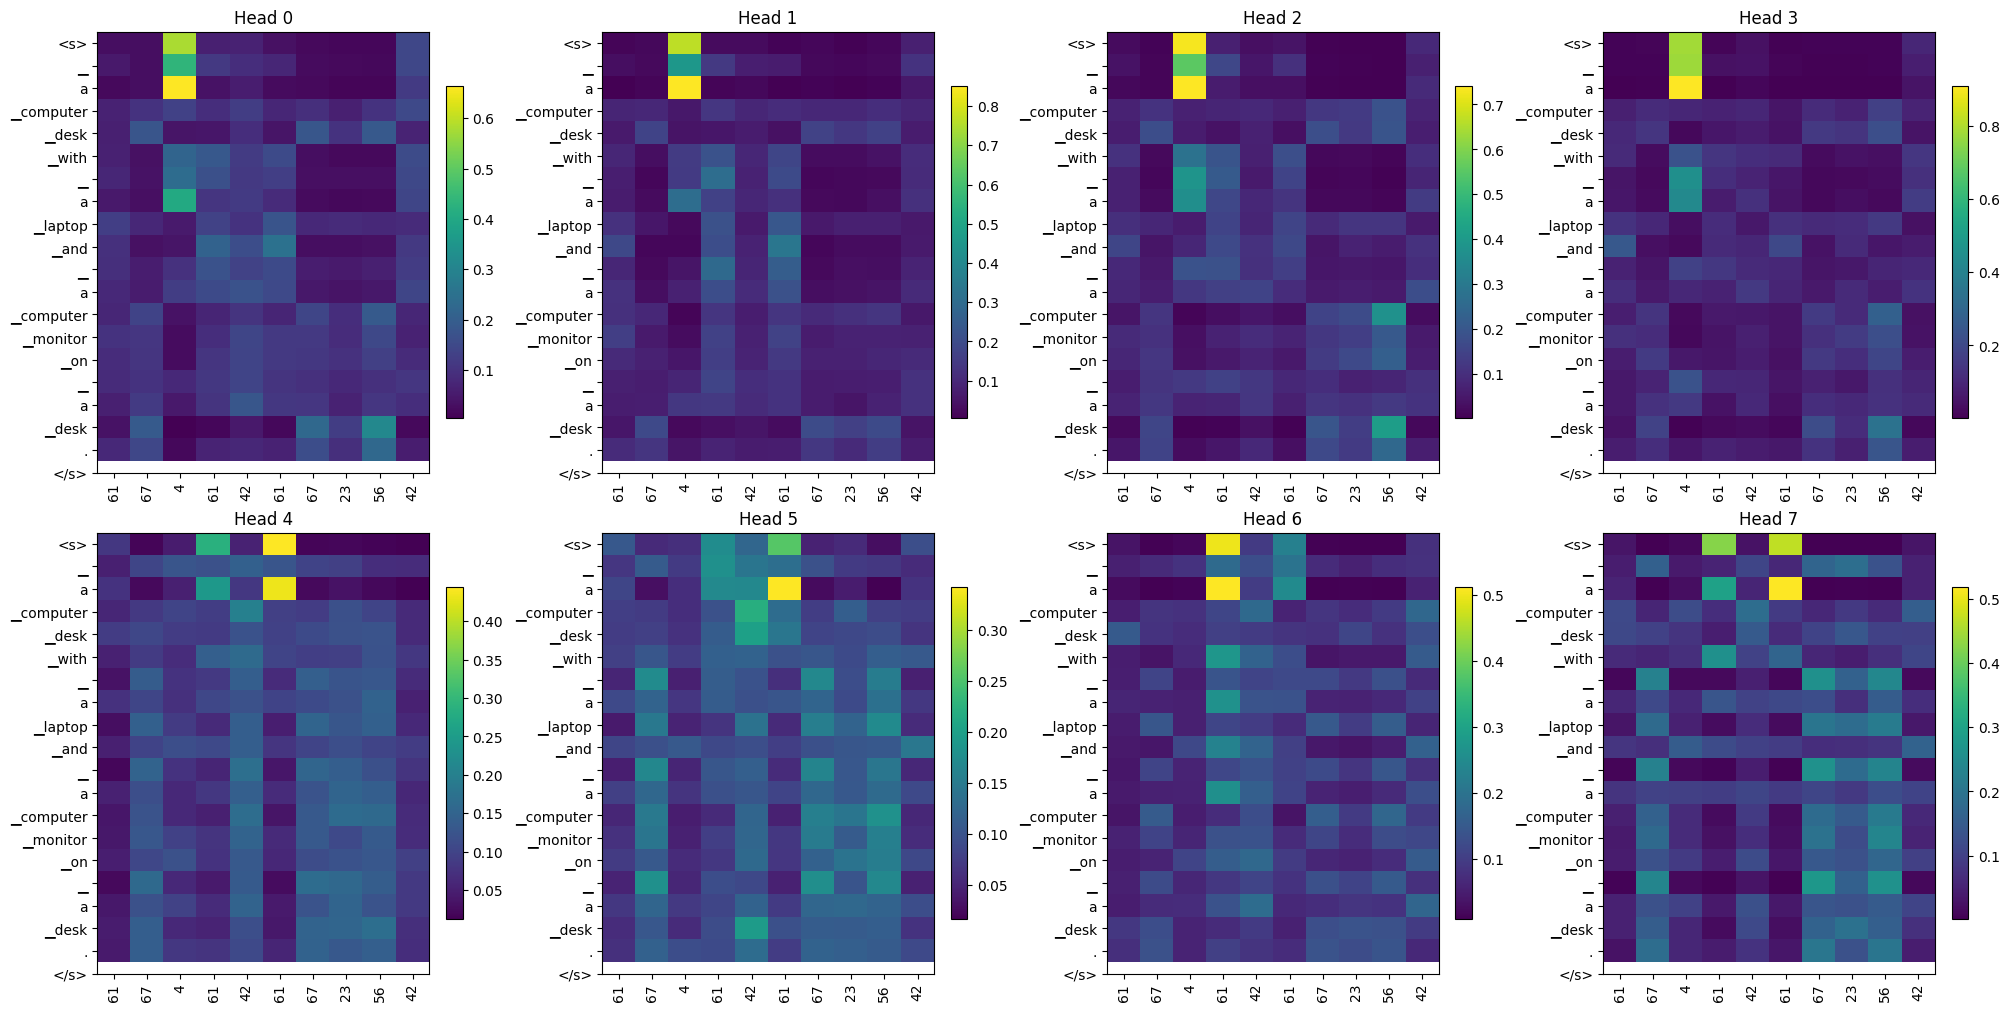

__
__________
Target text: a cow stares as it stands next to a body of water 


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 17, 10])
Visualizing 8 attention heads


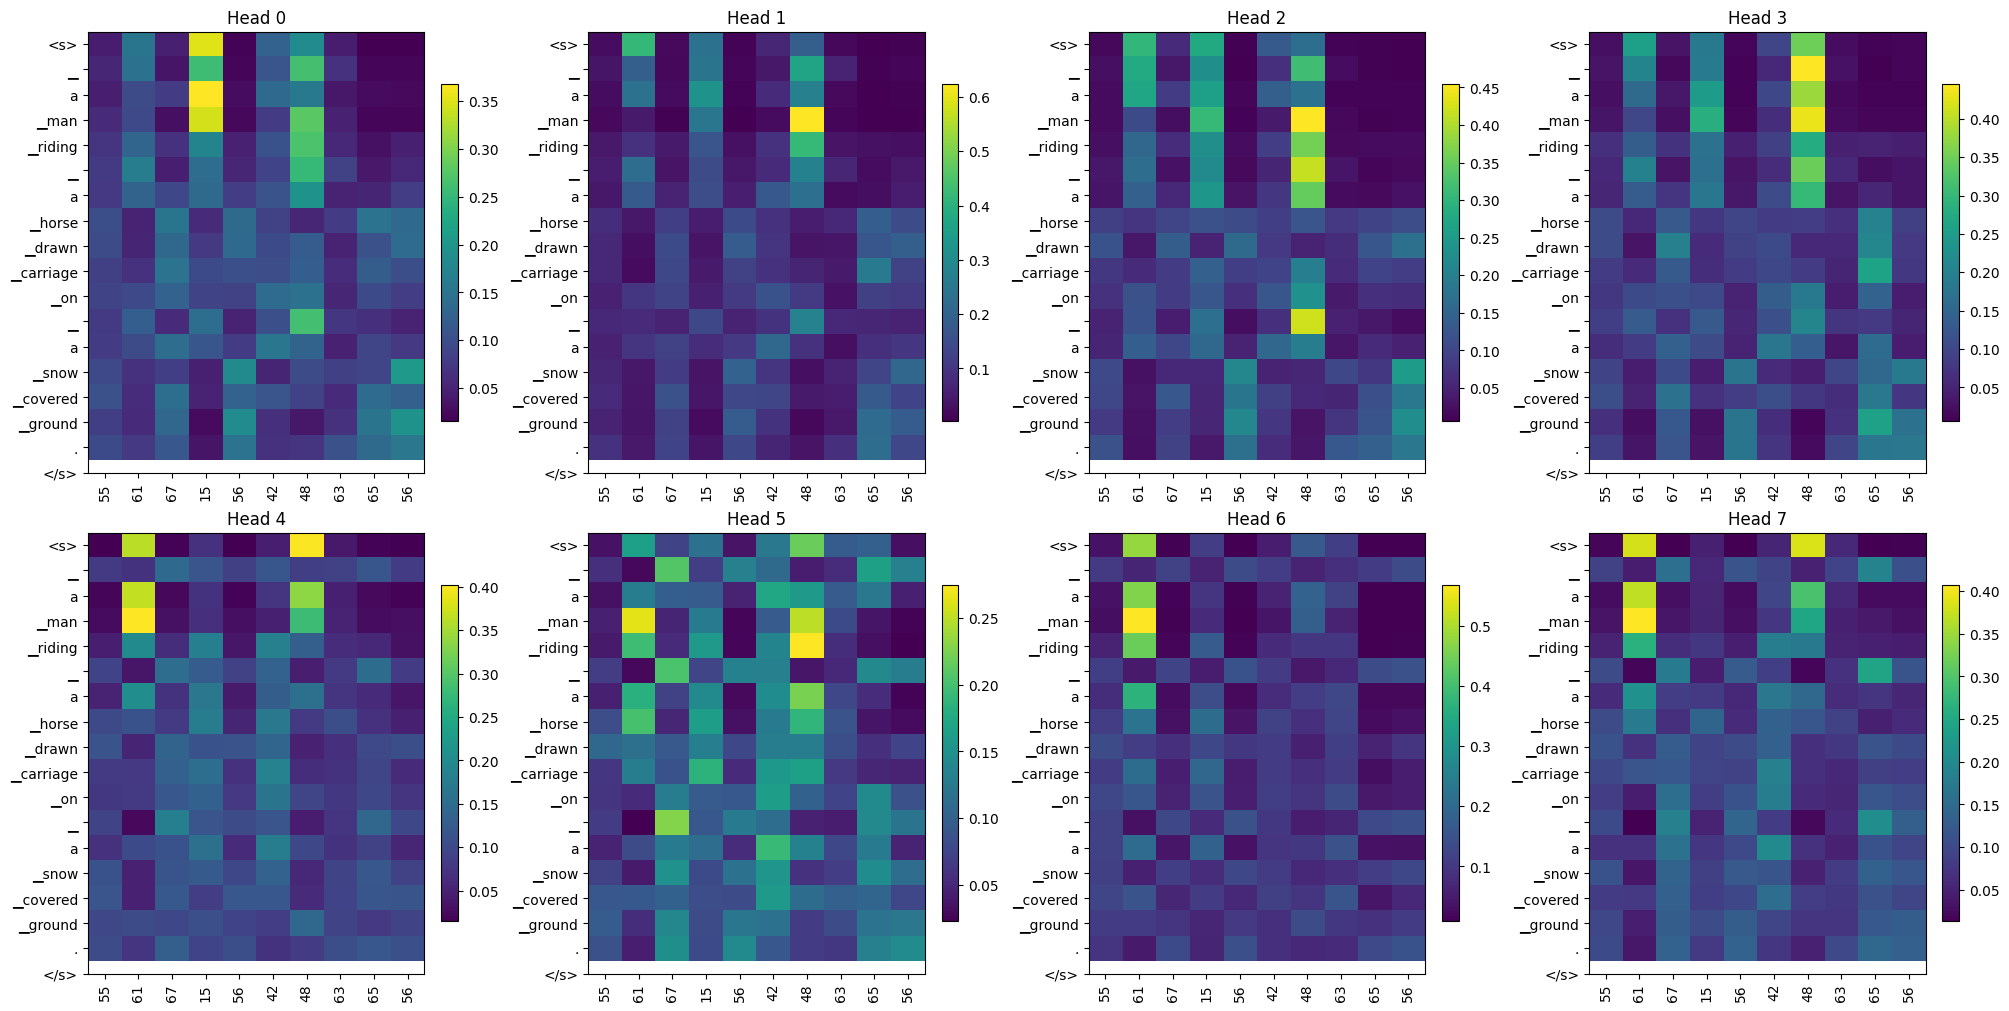

__
__________
Target text: Fresh fruit cart containing oranges and pears on it


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 19, 10])
Visualizing 8 attention heads


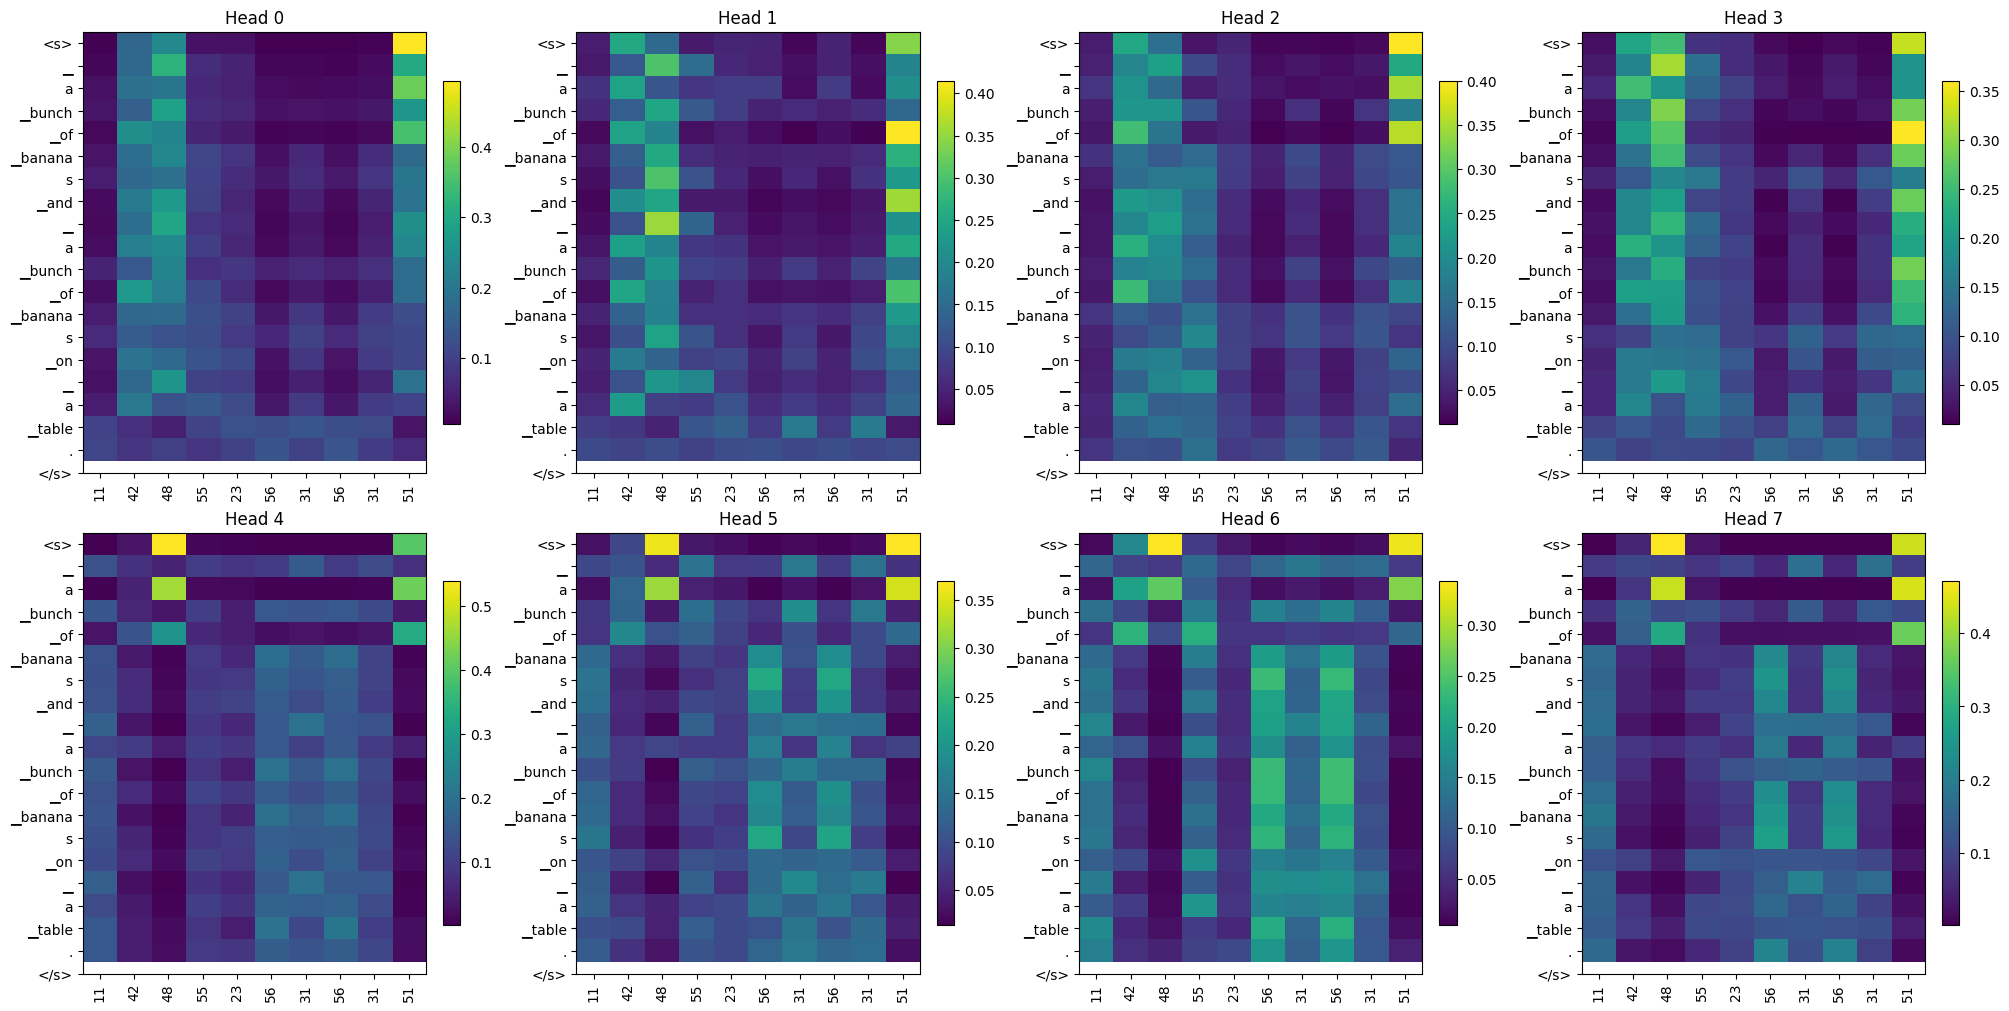

__
__________
Target text: The clock shown above has someone's name on it.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 16, 10])
Visualizing 8 attention heads


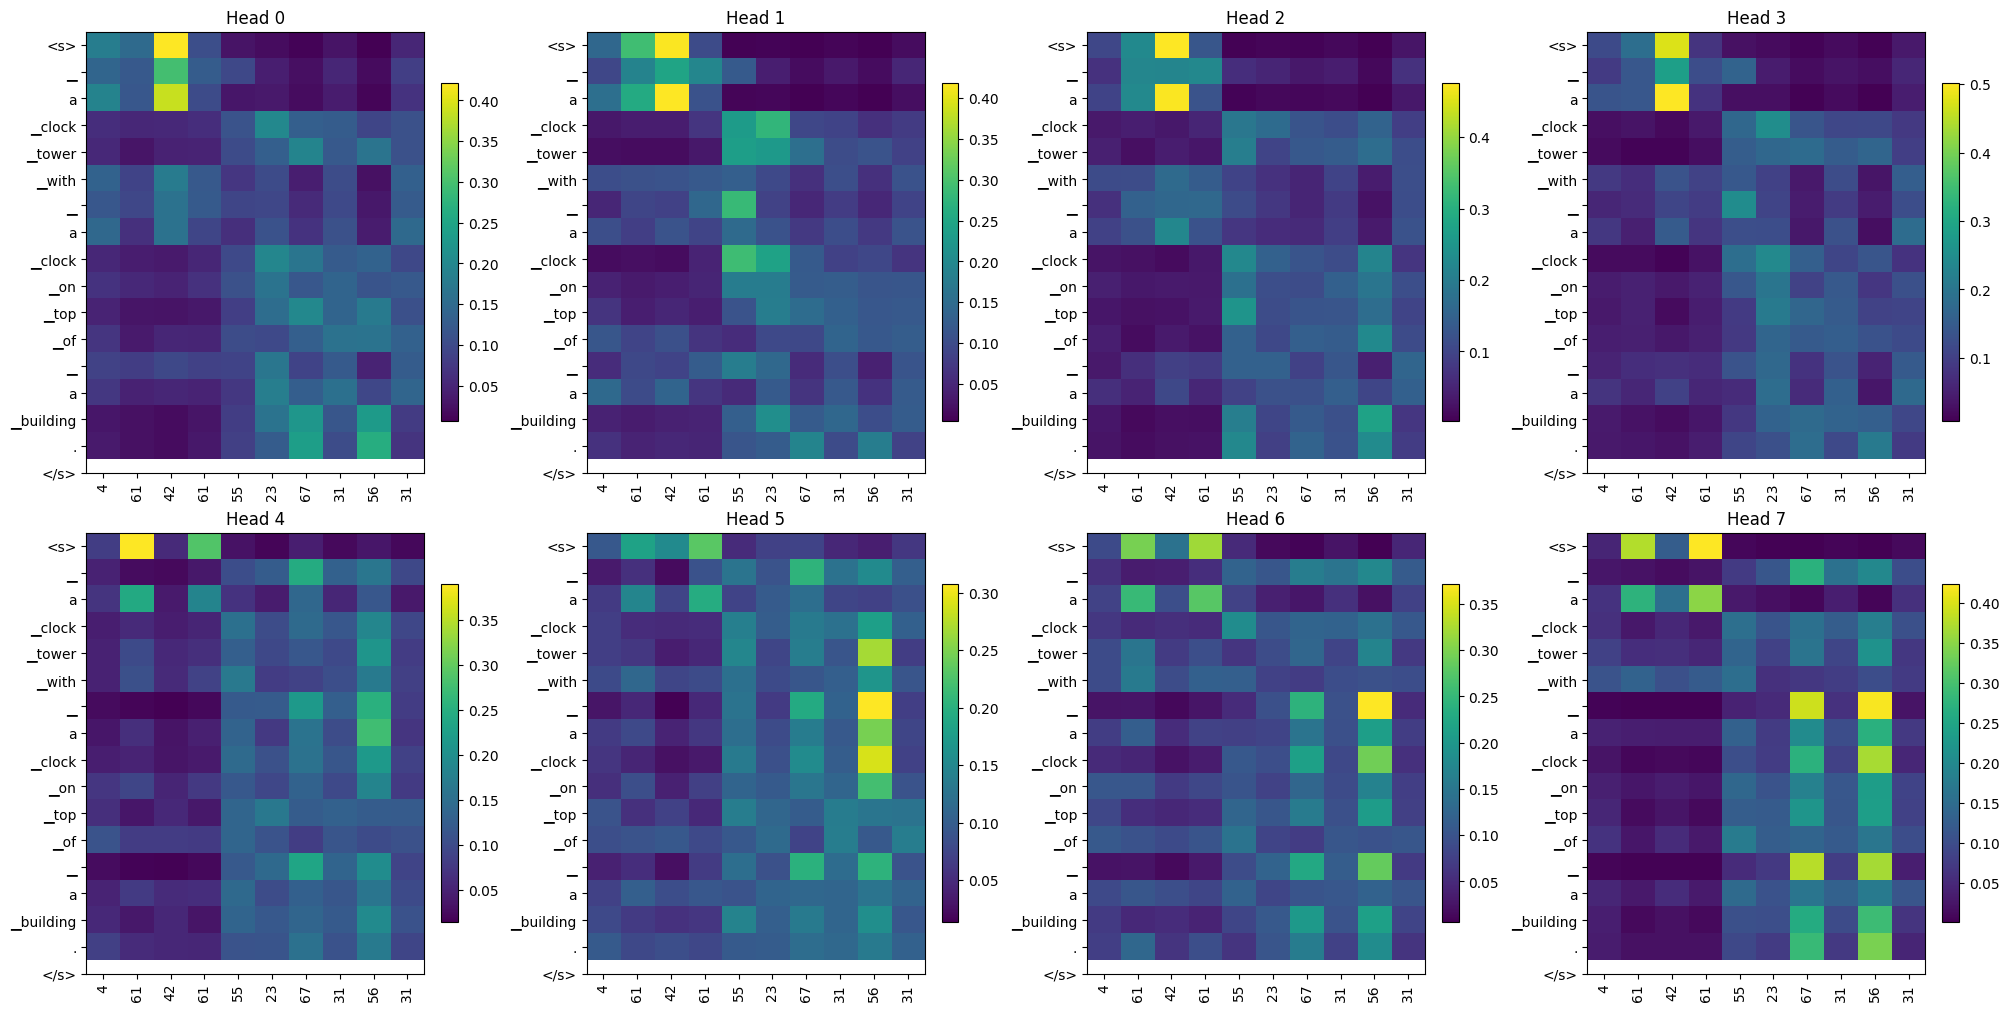

__
__________
Target text: A living room filled with furniture and  set of glass doors.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 16, 10])
Visualizing 8 attention heads


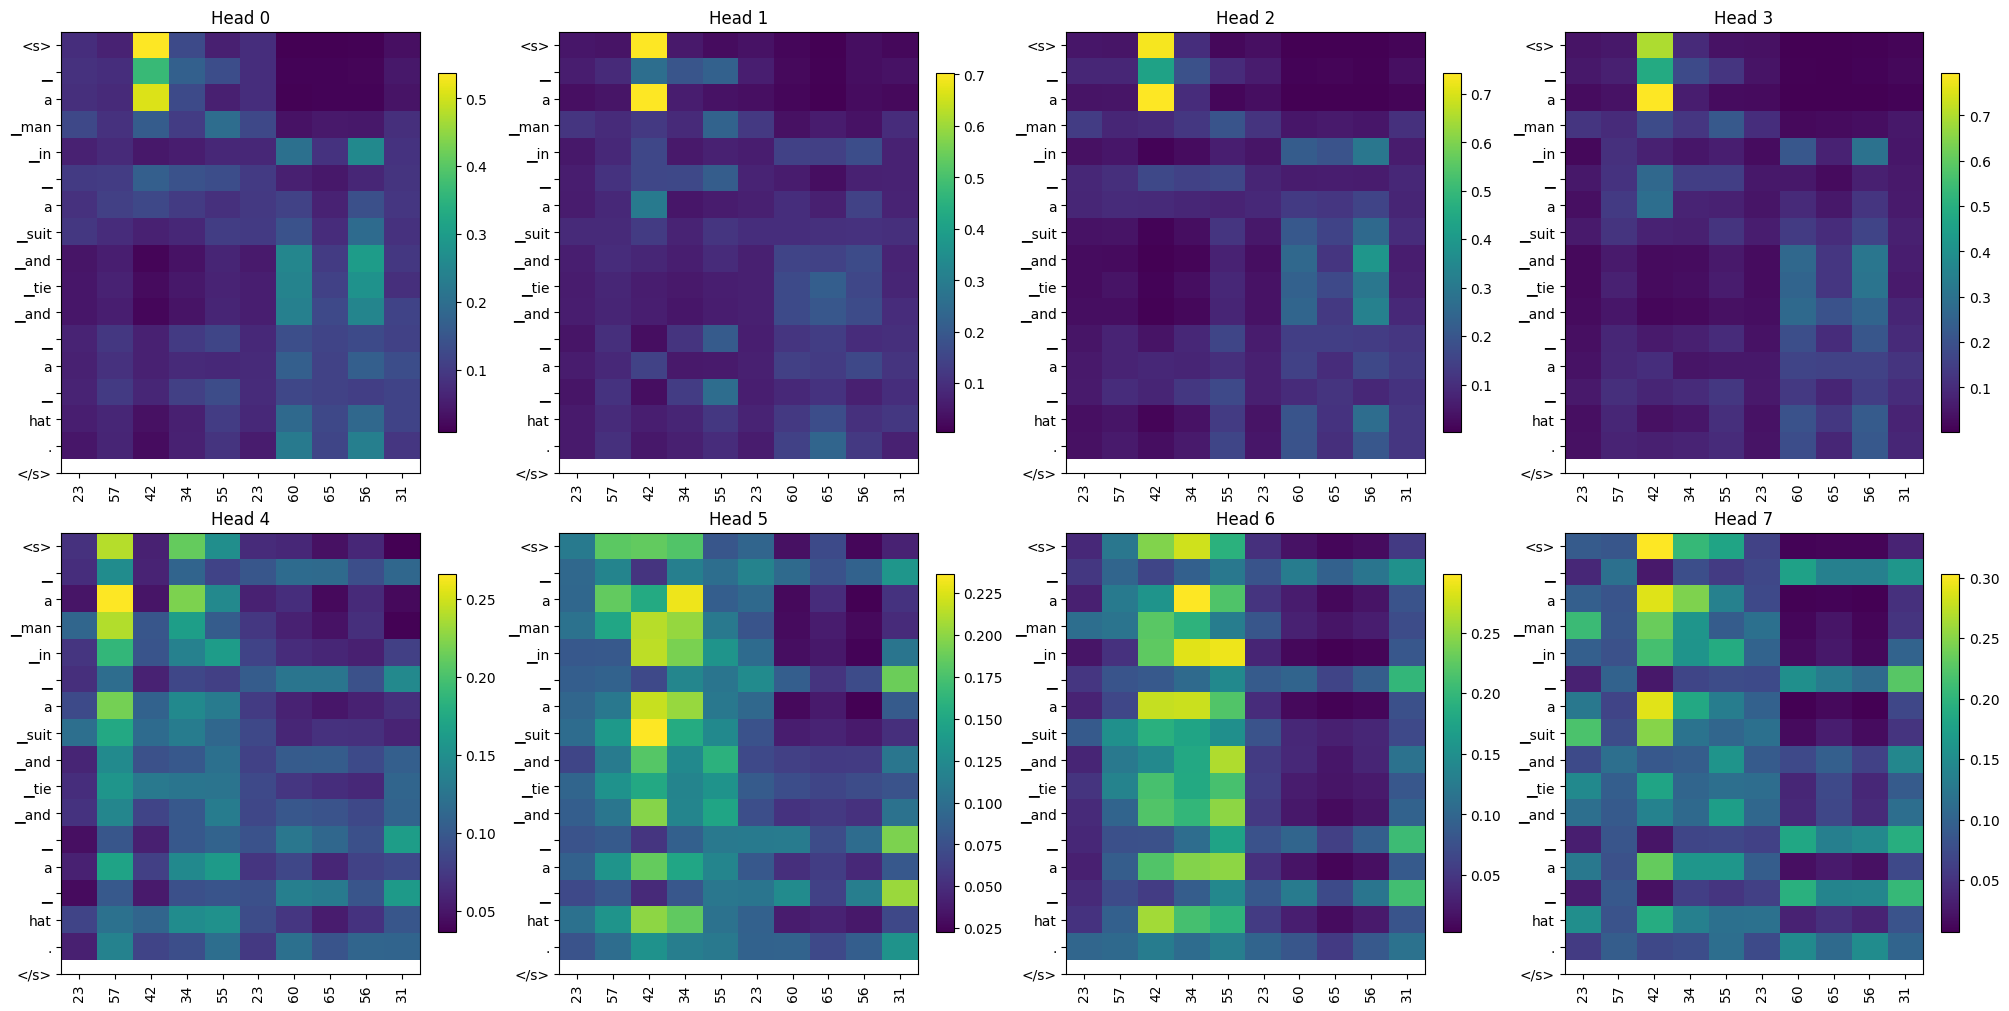

__
__________
Target text: Two women sitting outside hanging out and smoking cigarettes.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 15, 10])
Visualizing 8 attention heads


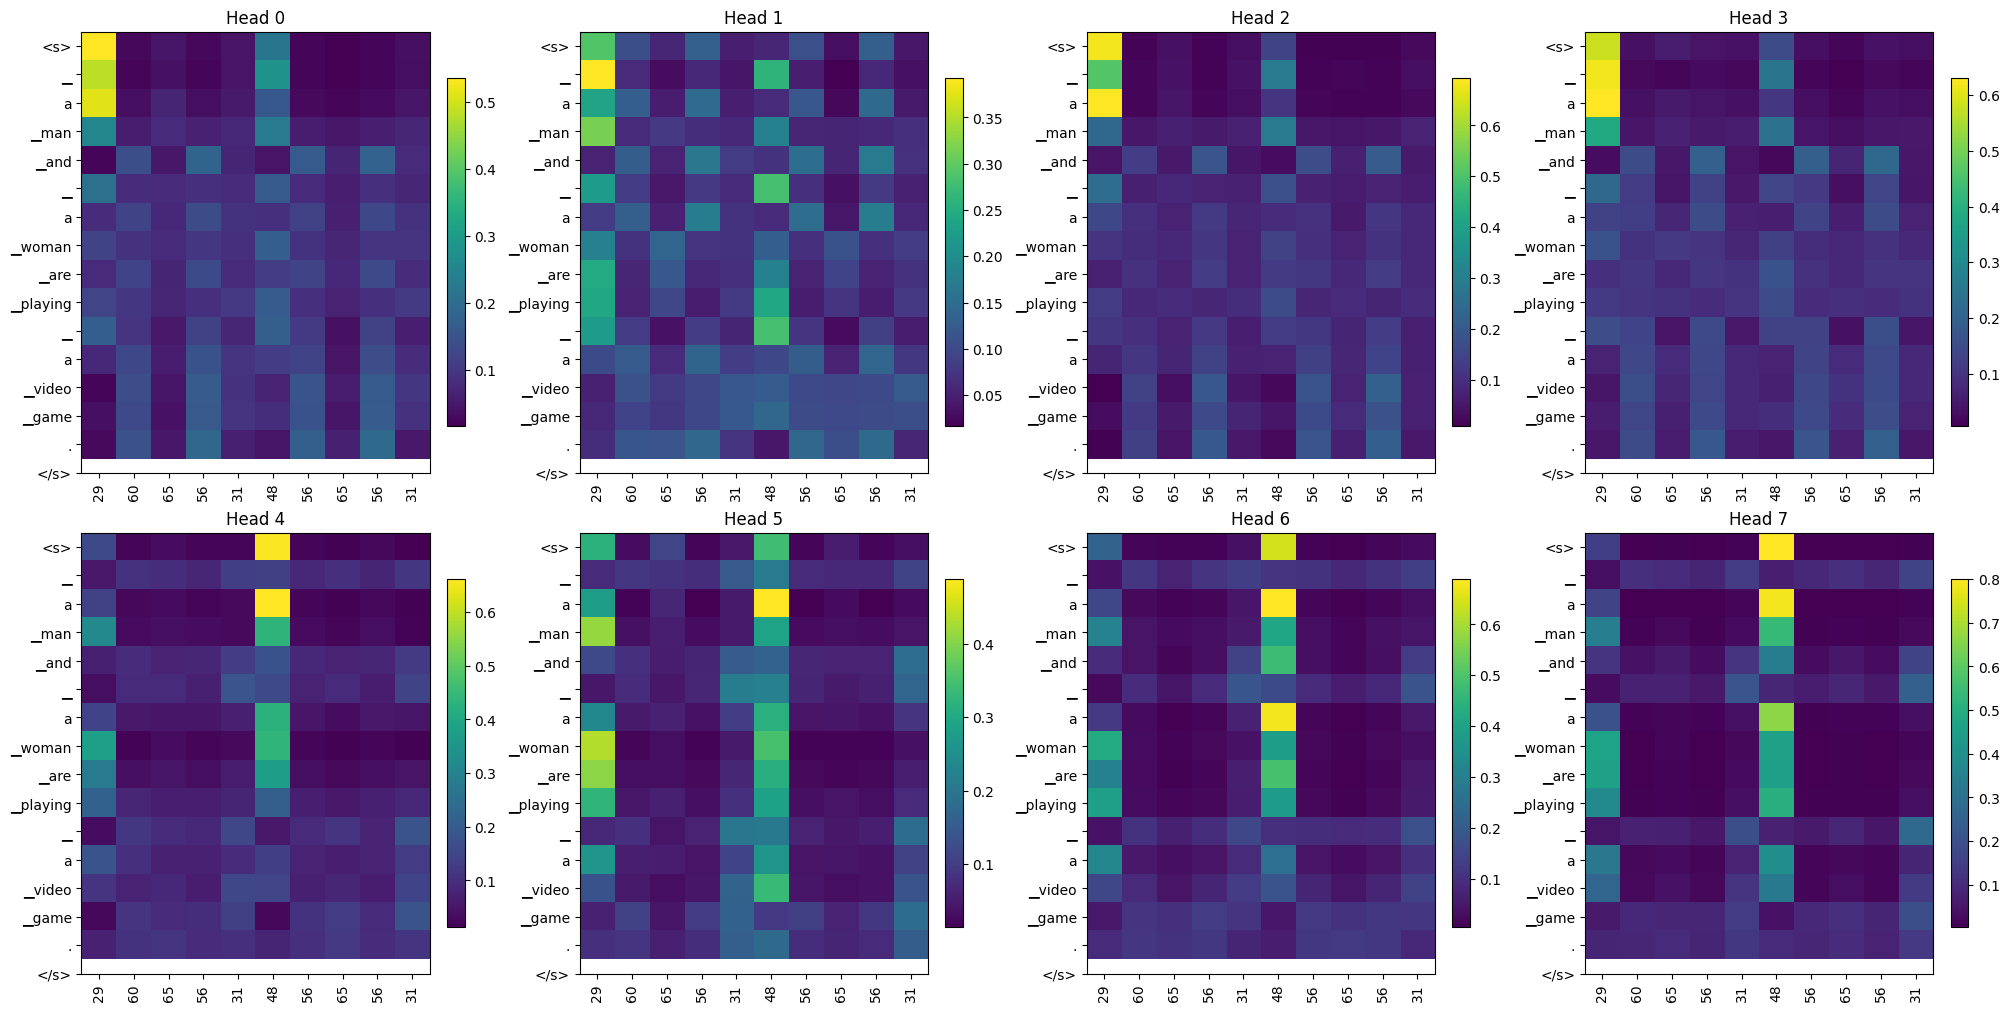

__
__________
Target text: A teenager doing skateboard tricks at a skate park


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 20, 10])
Visualizing 8 attention heads


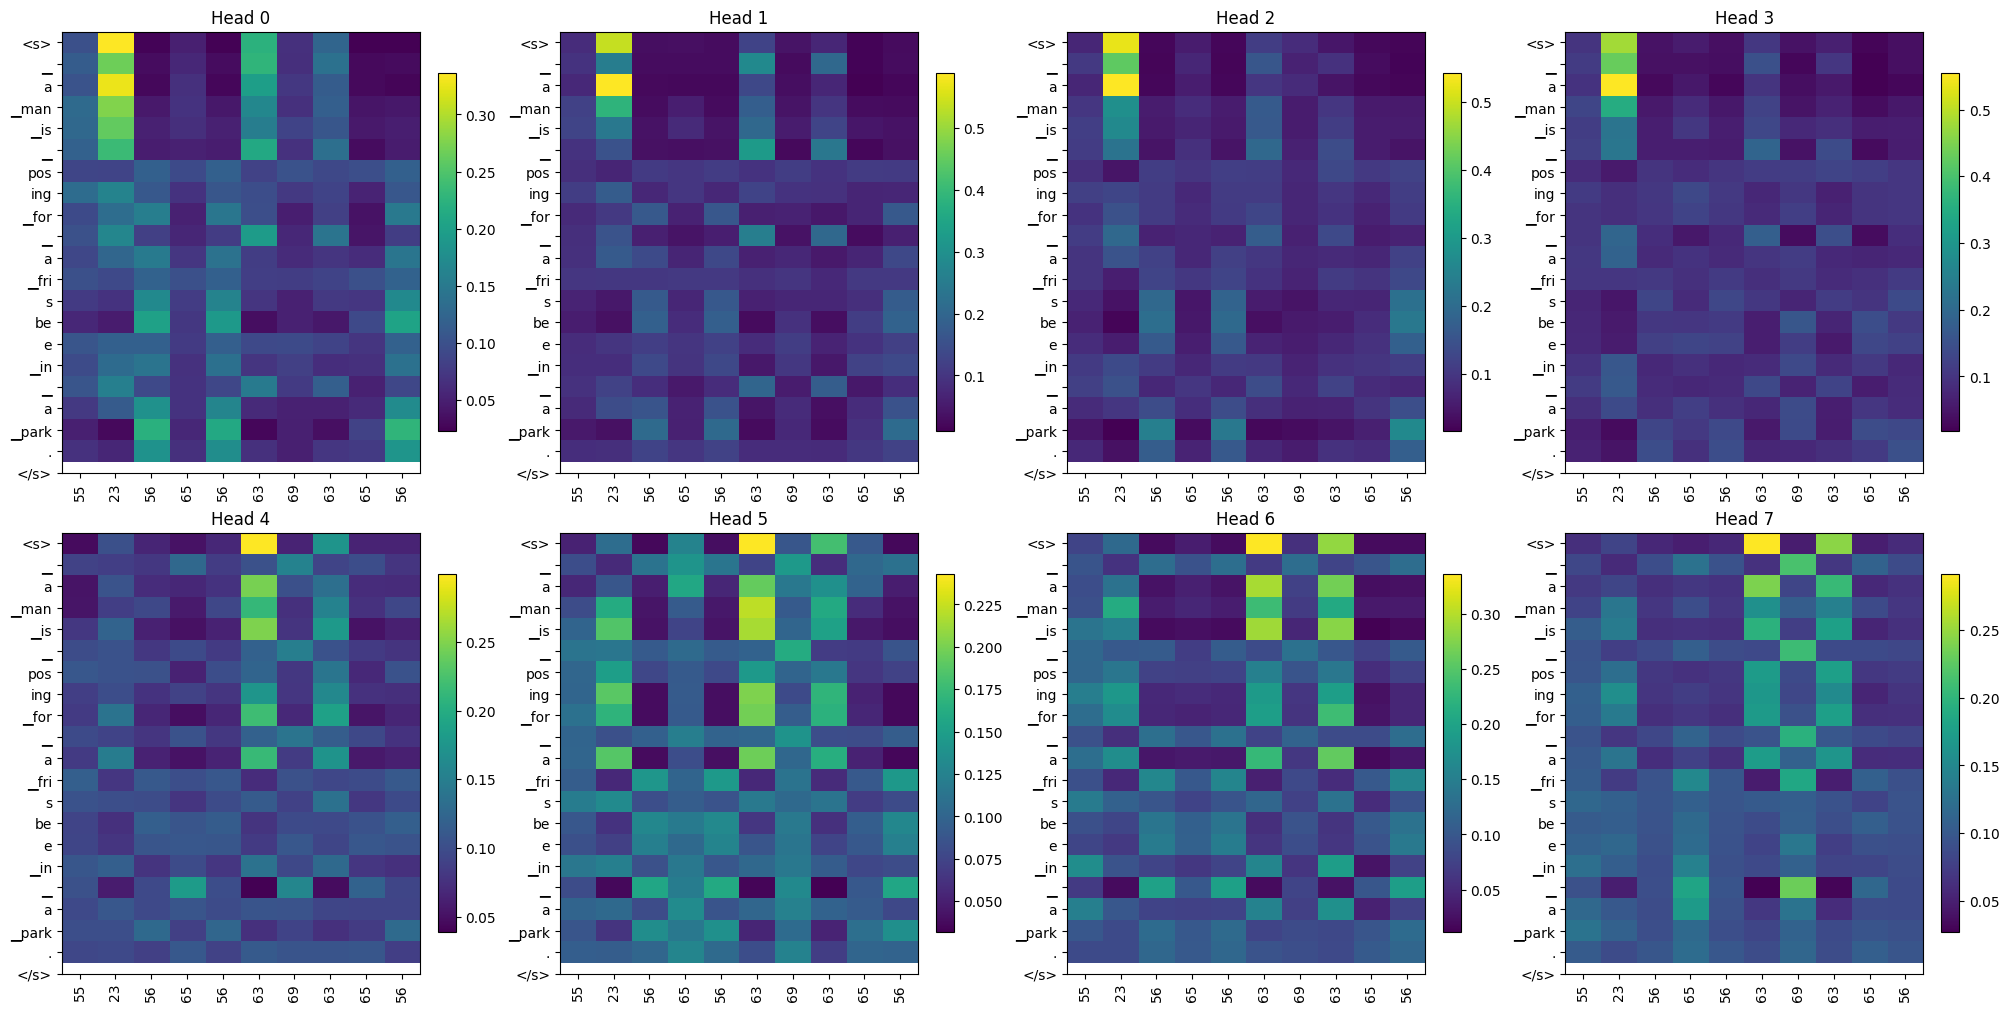

__
__________
Target text: A street scene of a self service parking lot.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 16, 10])
Visualizing 8 attention heads


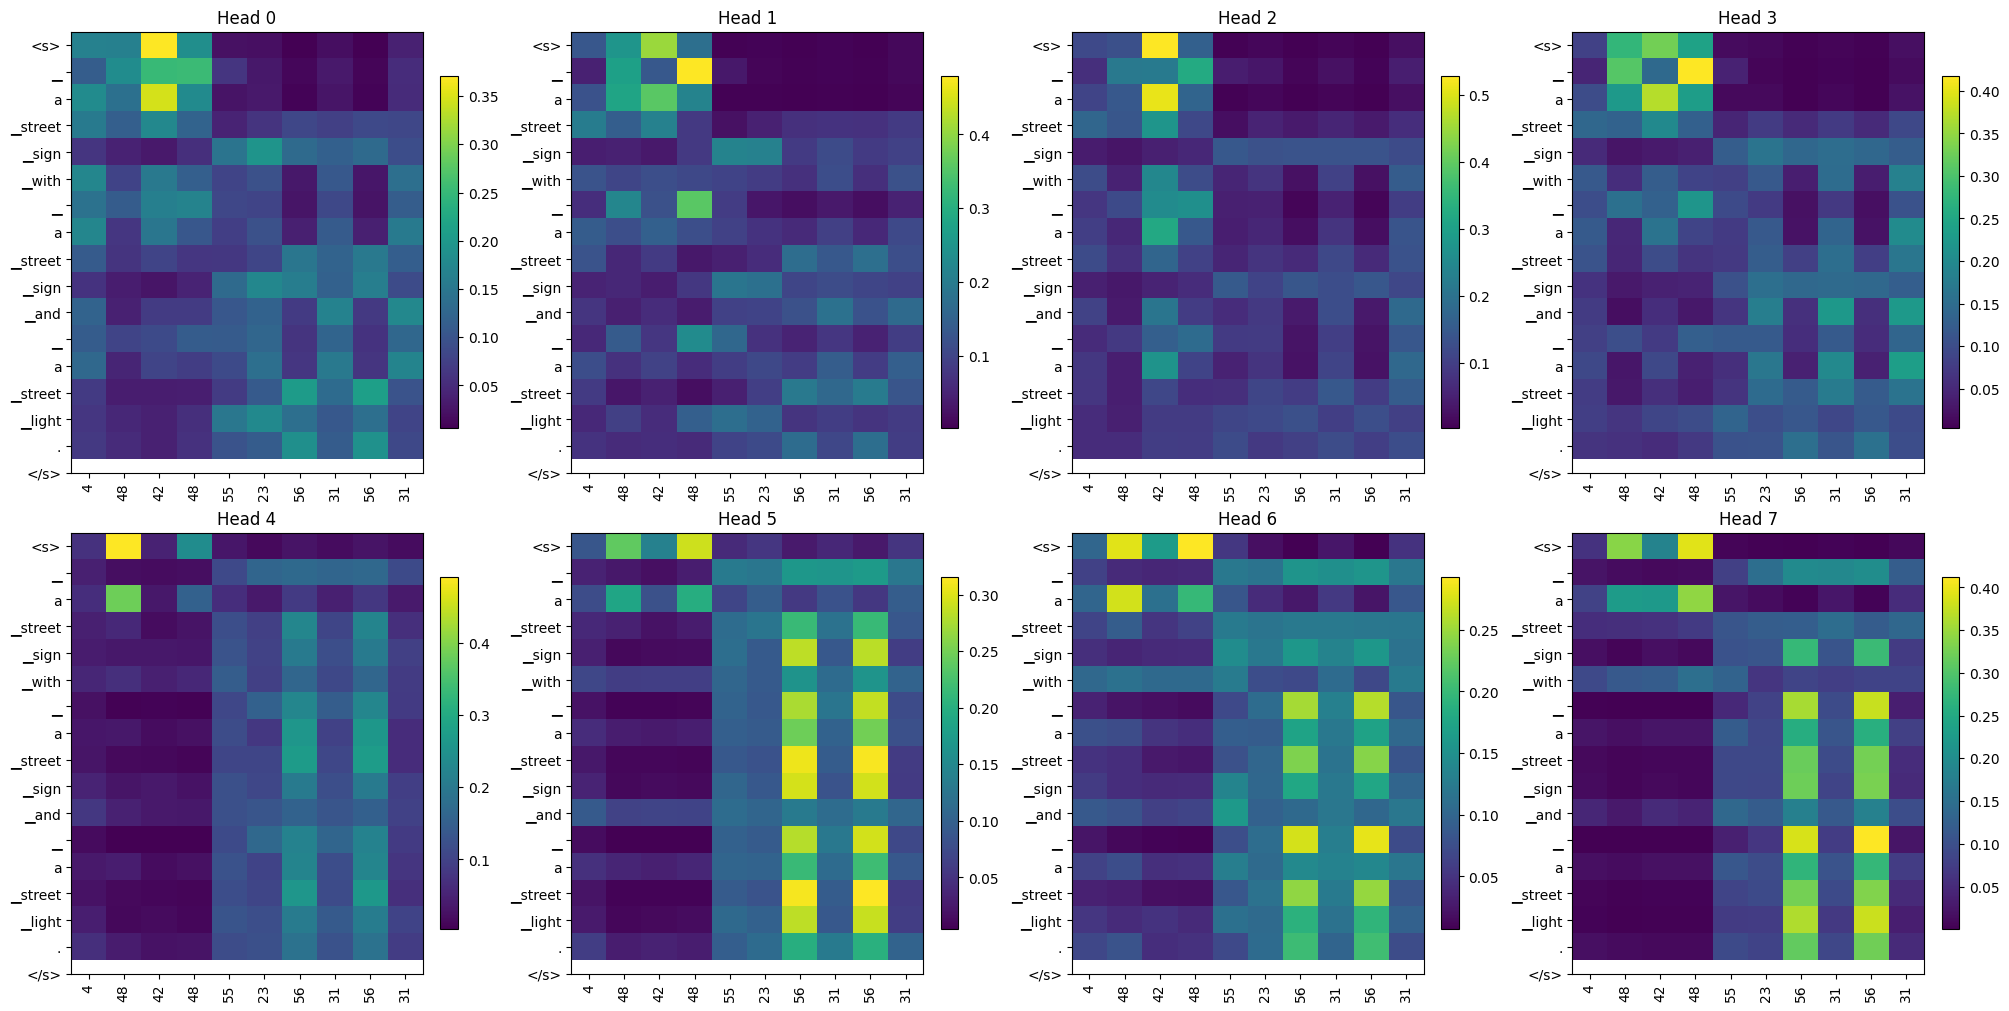

__
__________
Target text: a wooden cutting board a knife some carrots and onions


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 15, 10])
Visualizing 8 attention heads


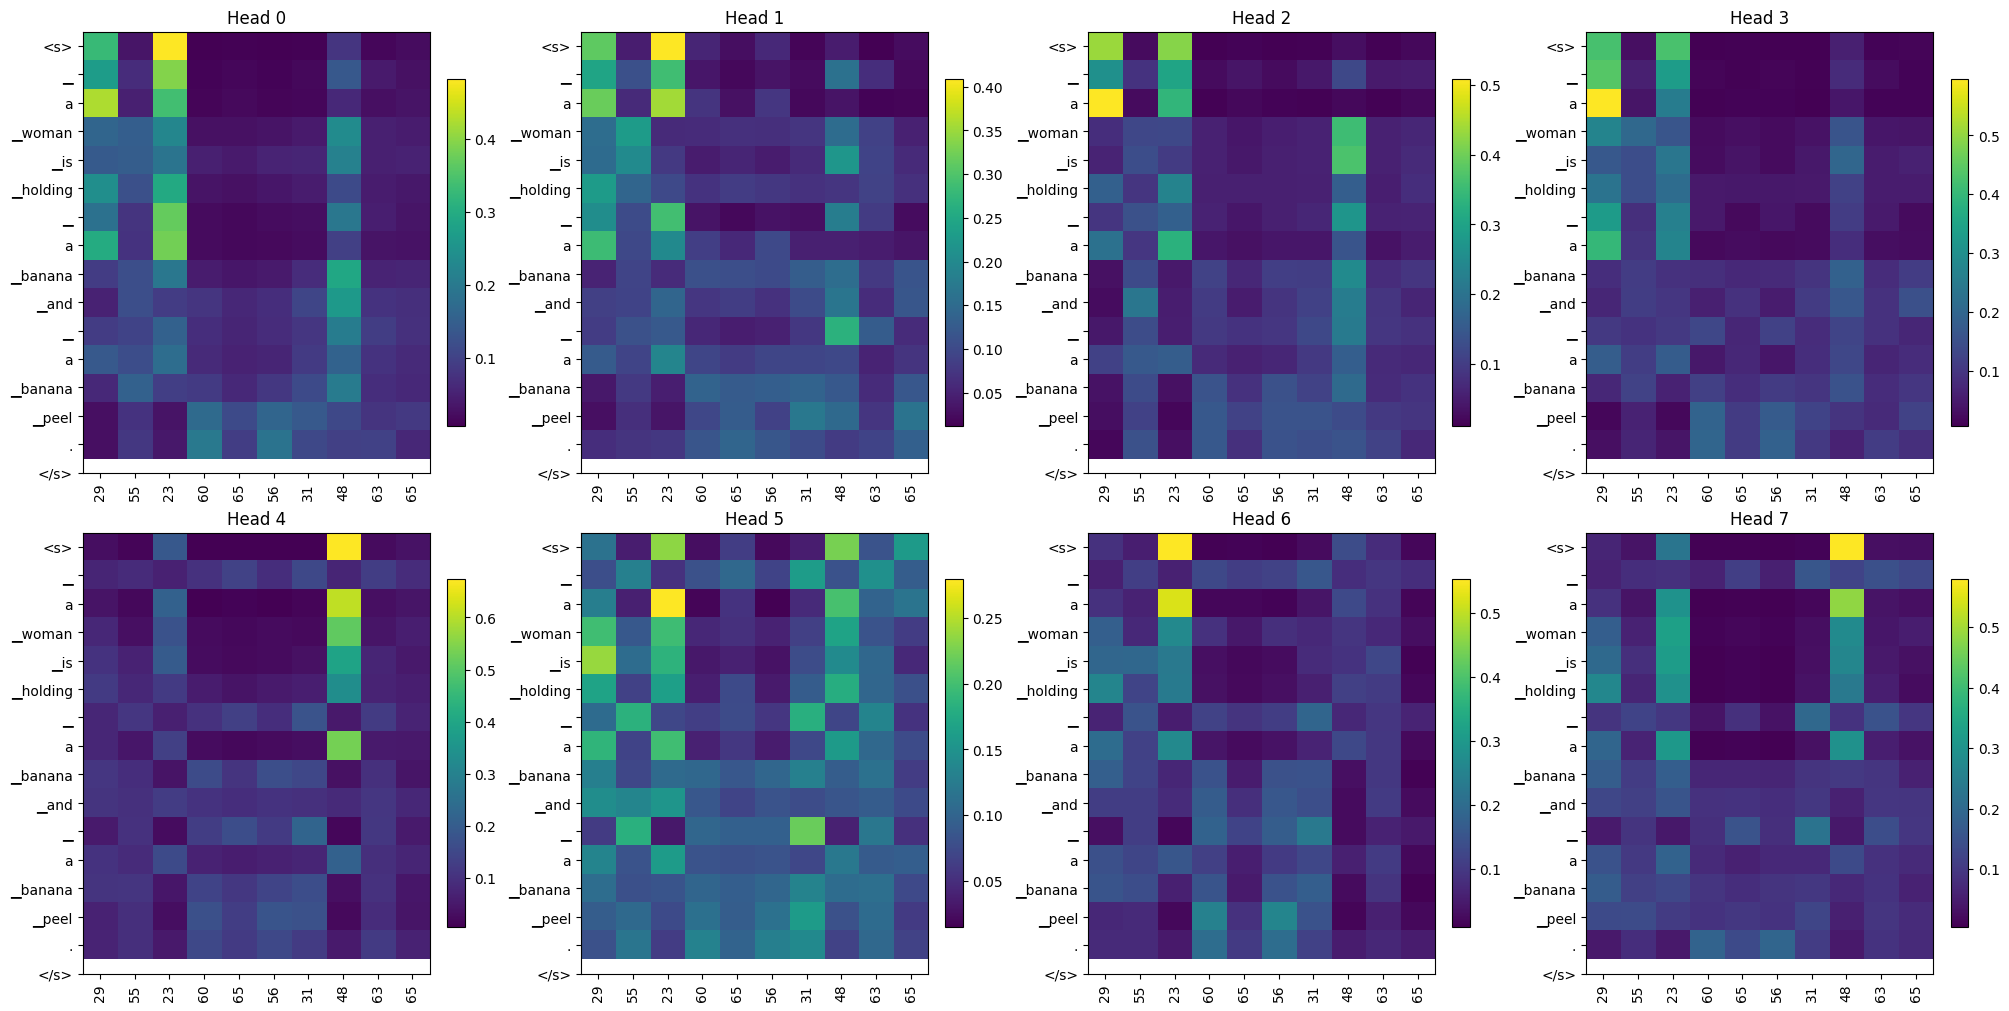

__
__________
Target text: A herd of elephants splashing and playing in a river.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 15, 10])
Visualizing 8 attention heads


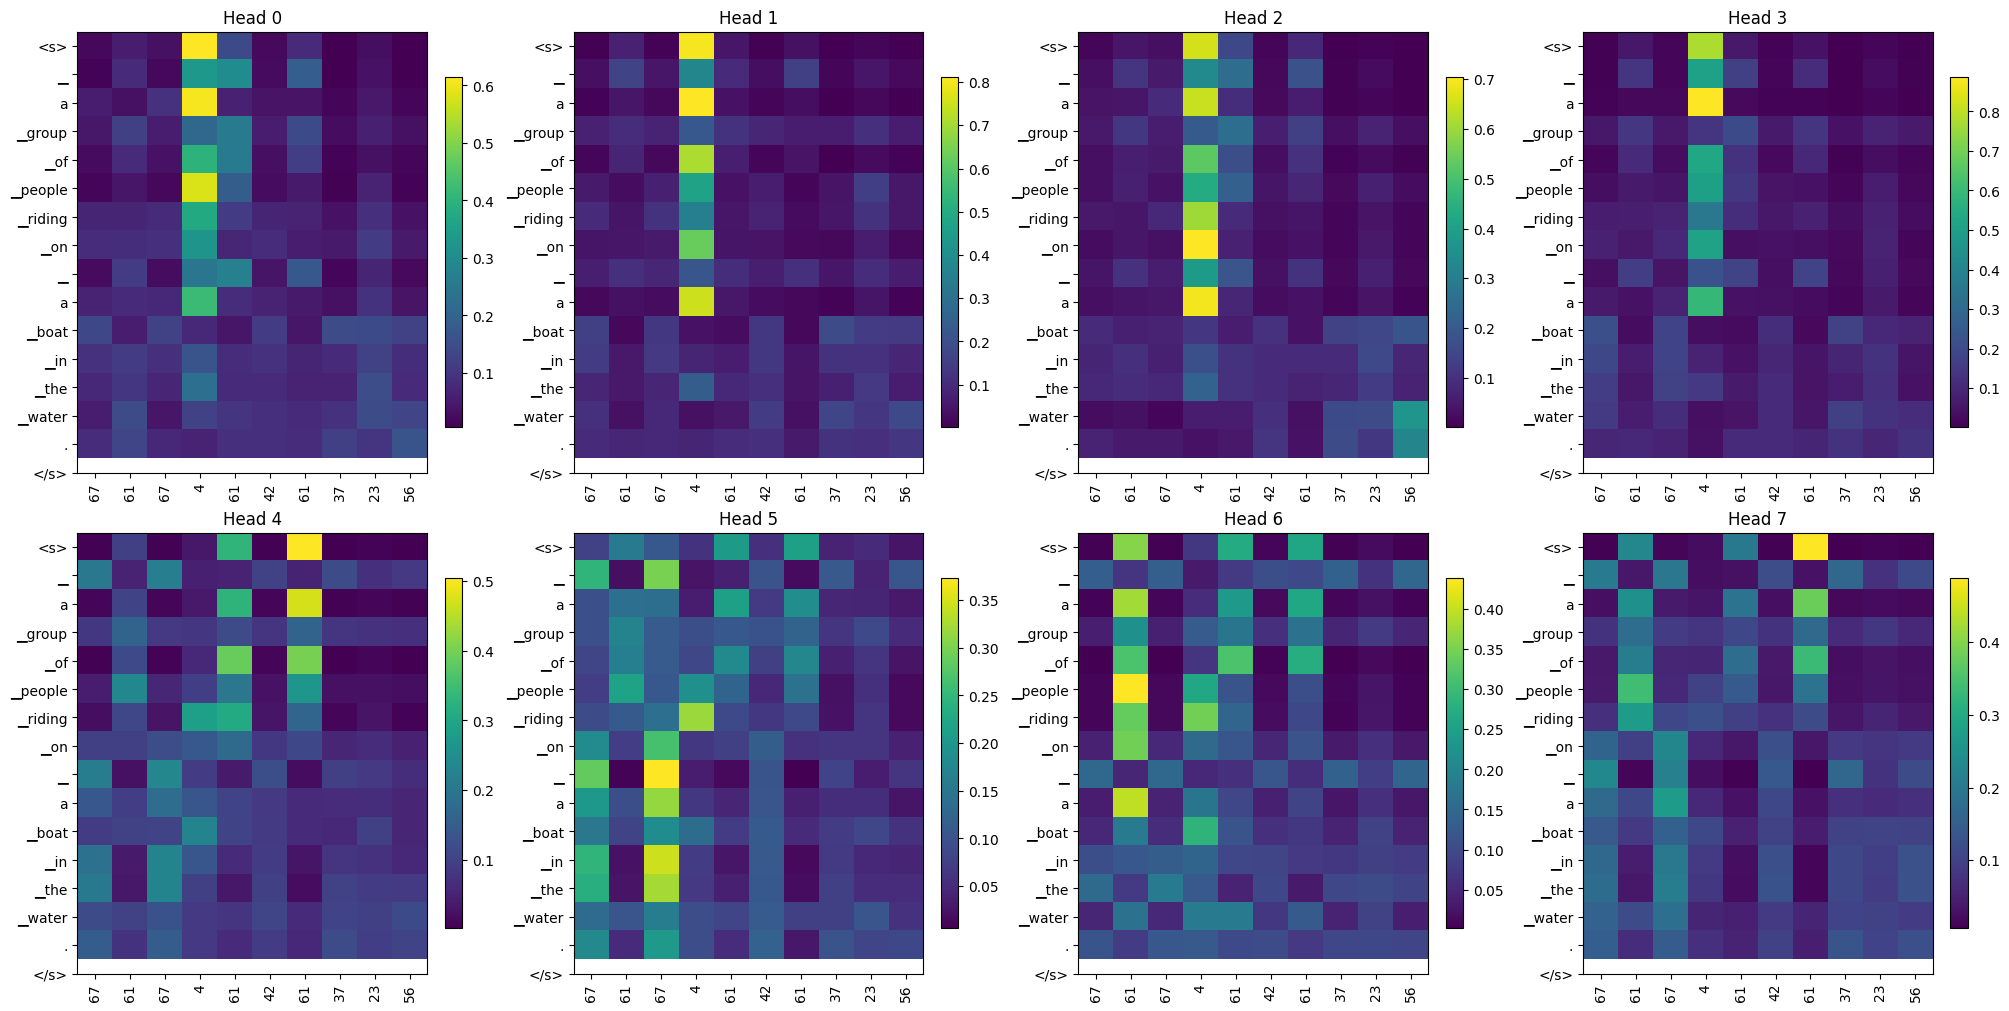

__
__________
Target text: A person on a skateboard on a skate ramp.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 19, 10])
Visualizing 8 attention heads


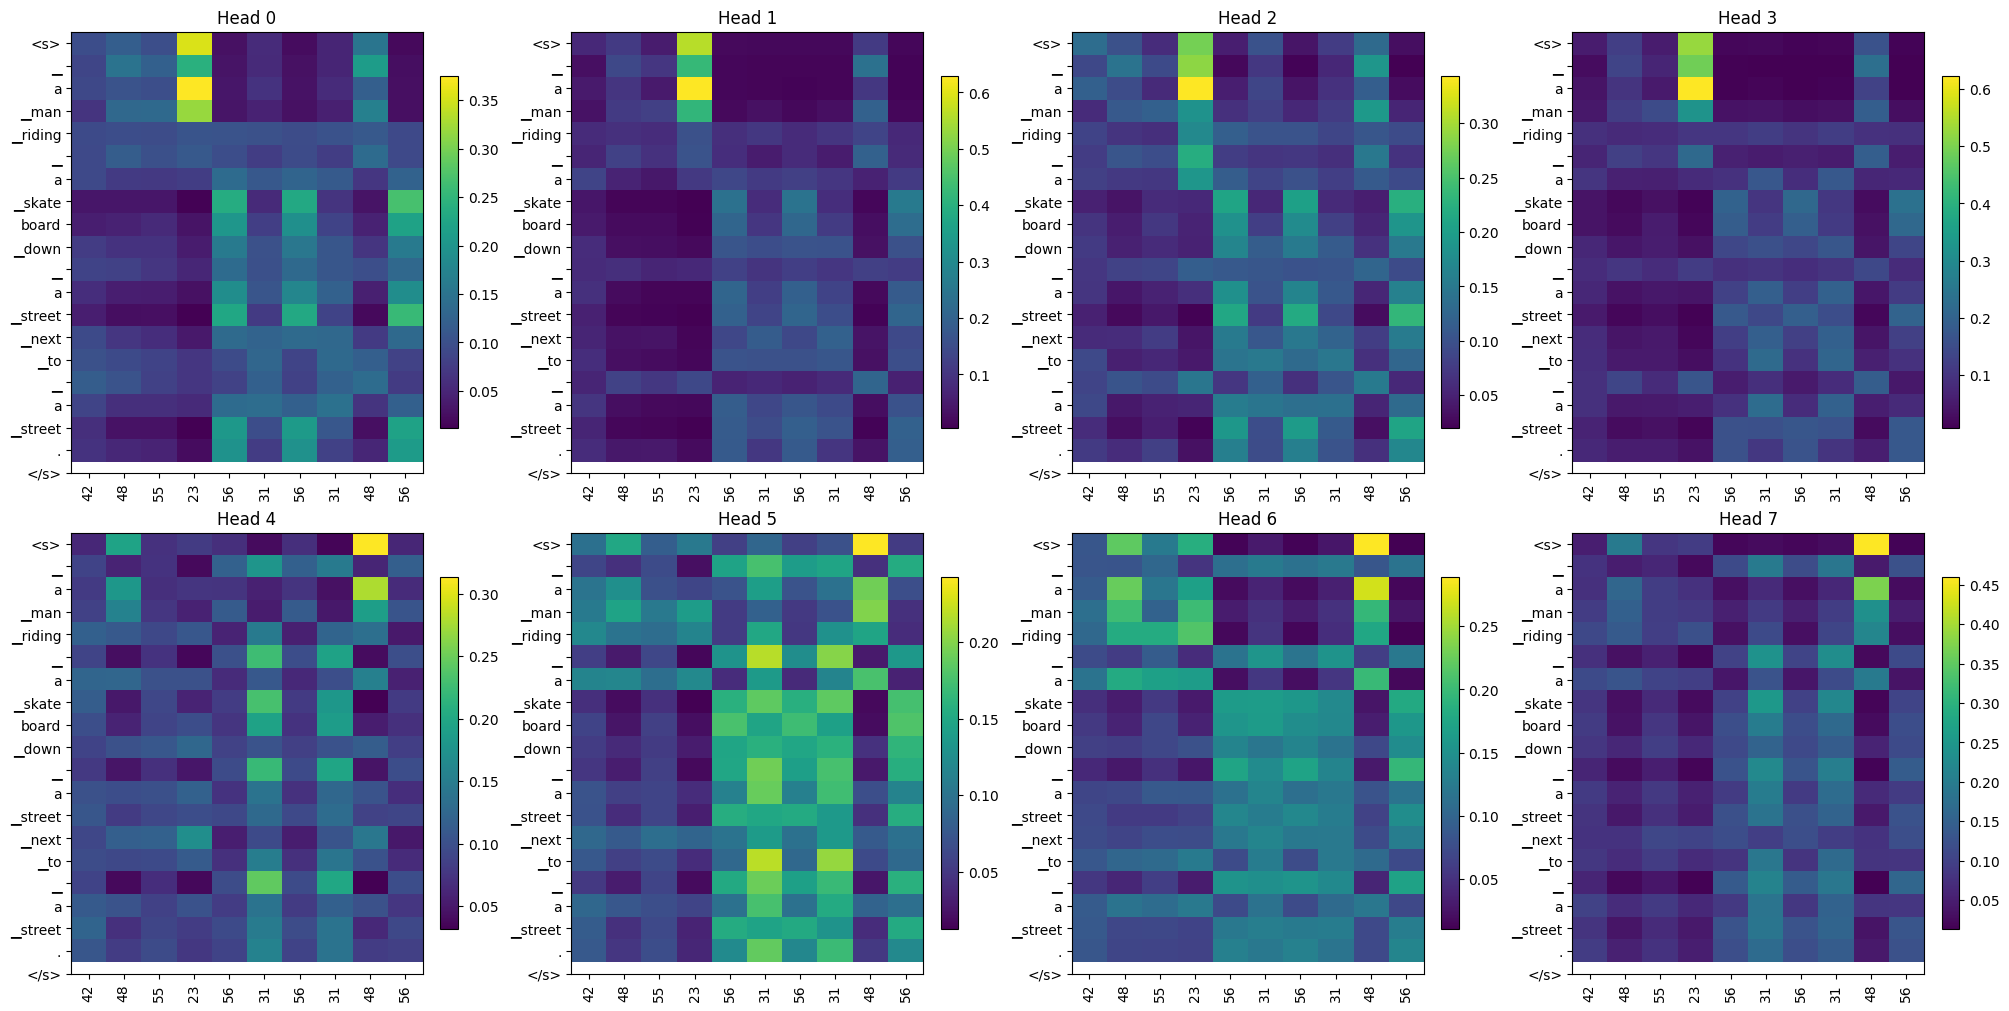

__
__________
Target text: A giraffe has come to a fence line to greet visitors.


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Attention shape: torch.Size([8, 19, 10])
Visualizing 8 attention heads


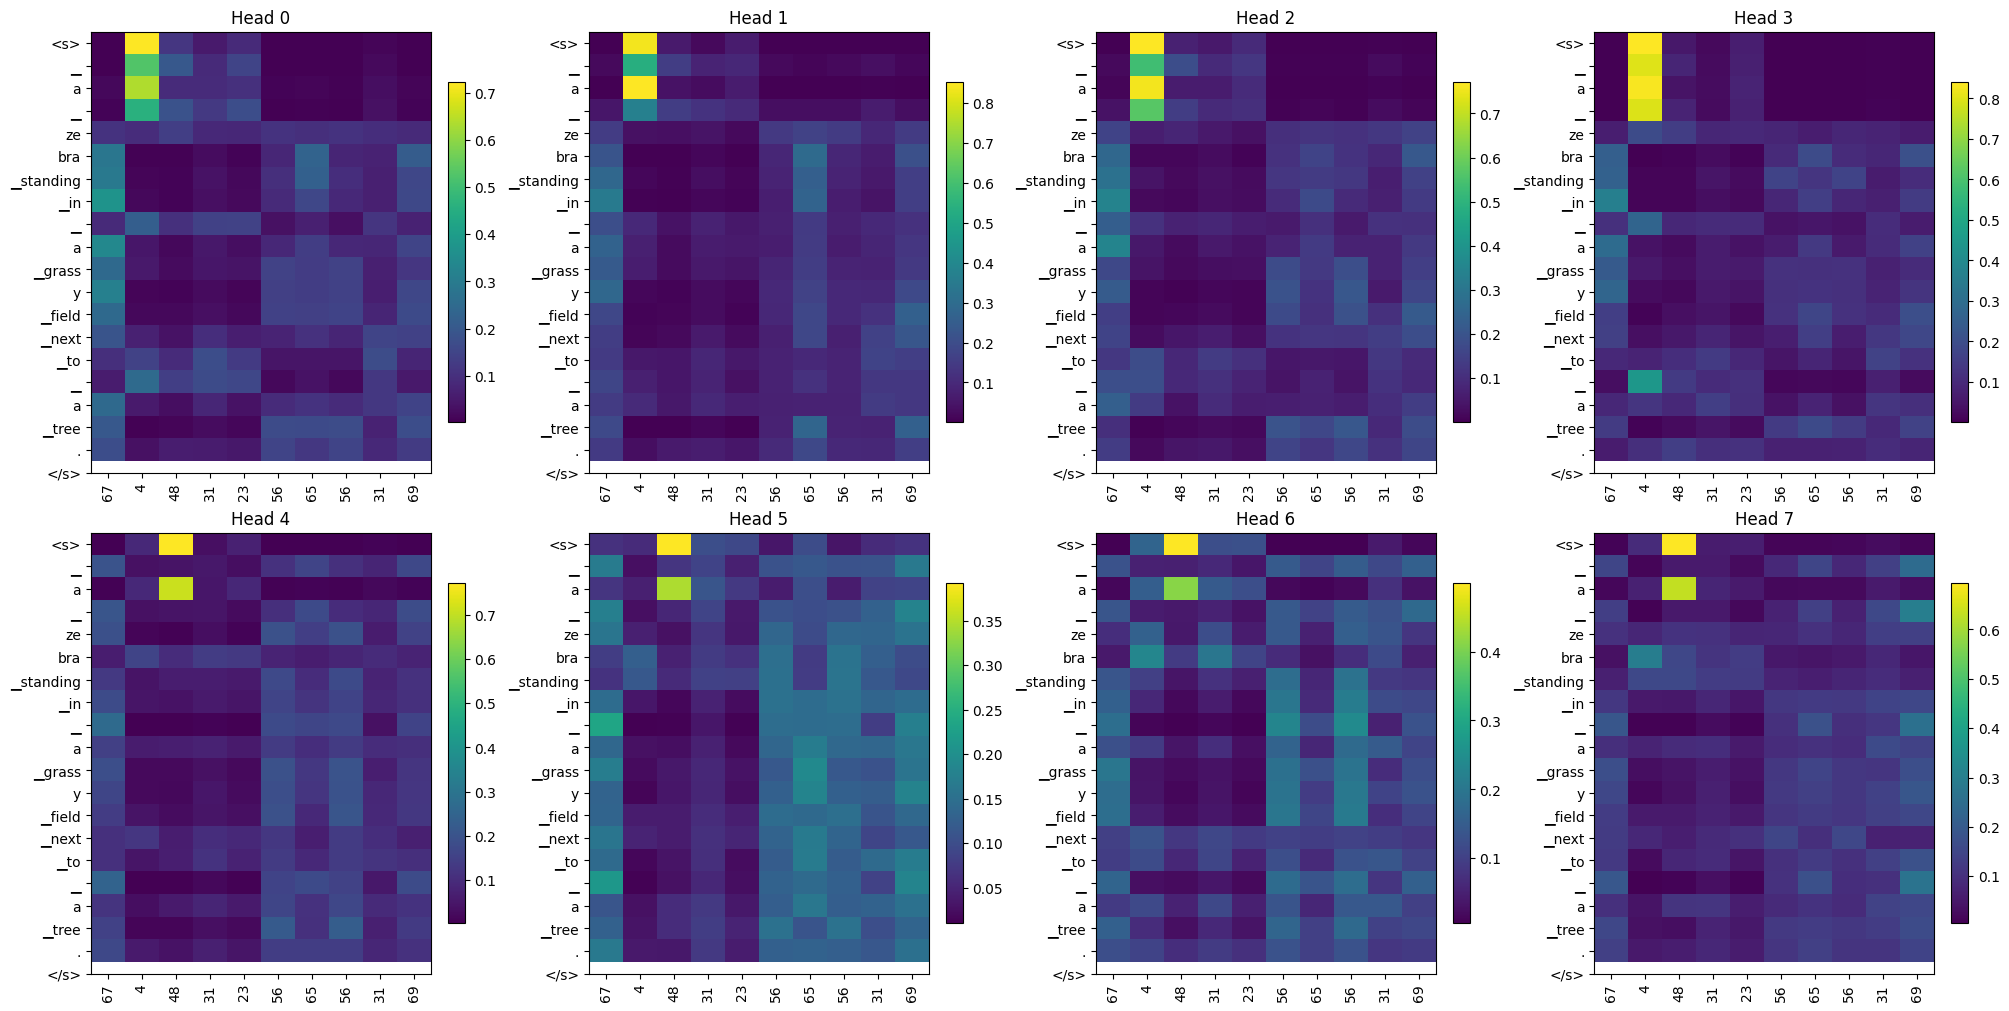

__


In [8]:
for i in range(0,15,1):
    decoder_attention(i)
    print('__')

In [21]:
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoTokenizer
from translation import TransformerEncoder, TransformerDecoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def self_attention(sample_id):

    dataset = load_from_disk("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/messages/coco_val_message_captions_3_distractors")
    sample = dataset[sample_id]

    tokenizer = AutoTokenizer.from_pretrained("t5-small")
    if tokenizer.bos_token is None:
        tokenizer.add_special_tokens({'bos_token': '<s>'})

    src = torch.tensor(sample["message_truncated"]).unsqueeze(0).to(DEVICE)
    ref_text = sample["captions"][0]

    tgt = tokenizer(ref_text, return_tensors="pt")["input_ids"].to(DEVICE)

    encoder = TransformerEncoder(
        vocab_size=71,
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=70,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    decoder = TransformerDecoder(
        vocab_size=len(tokenizer.vocab),
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=tokenizer.pad_token_id,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    checkpoint = torch.load("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/translation/checkpoint.pt", map_location=DEVICE)

    encoder.load_state_dict(checkpoint["encoder"])
    decoder.load_state_dict(checkpoint["decoder"])

    encoder.to(DEVICE).eval()
    decoder.to(DEVICE).eval()
    # decoder.transformer.layers[-1].multihead_attn.need_weights = True

    # ---------------- hook ----------------
    attention = {}

    layer = encoder.transformer.layers[-1].self_attn
    orig_forward = layer.forward

    def new_forward(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        out = orig_forward(*args, **kwargs)
        attention["weights"] = out[1].detach()
        return out

    layer.forward = new_forward

    def hook(module, input, output):
        attention["weights"] = output[1].detach()

    encoder.transformer.layers[-1].self_attn.register_forward_hook(hook)
    # --------------------------------------
    
    with torch.no_grad():

        memory, _ = encoder(src)

        logits, _, _ = decoder(tgt[:, :-1], memory)

        pred = logits.argmax(-1)

    attn = attention["weights"][0]  # remove batch

    hyp_tokens = tokenizer.convert_ids_to_tokens(pred[0])
    src_tokens = [str(t.item()) for t in src[0]]

    visualize_attention(attn, hyp_tokens, src_tokens)#, heads=1)


# if __name__ == "__main__":


In [22]:
for i in range(10):
    self_attention(i)
    print('__')

RuntimeError: Error(s) in loading state_dict for TransformerDecoder:
	size mismatch for emb.weight: copying a param with shape torch.Size([30522, 256]) from checkpoint, the shape in current model is torch.Size([32102, 256]).
	size mismatch for fc.weight: copying a param with shape torch.Size([30522, 256]) from checkpoint, the shape in current model is torch.Size([32101, 256]).
	size mismatch for fc.bias: copying a param with shape torch.Size([30522]) from checkpoint, the shape in current model is torch.Size([32101]).